In [1]:
# nSTAT-python notebook example: HistoryExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import History, nspikeTrain, nstColl
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='HistoryExamples', output_root=OUTPUT_ROOT, expected_count=3)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# Test History
# Generate a nspikeTrain and define a set of history windows of interest. We desire windows from 1-2ms, 2-3ms, 3-5ms, and 5-10ms, then compute the corresponding history covariates.

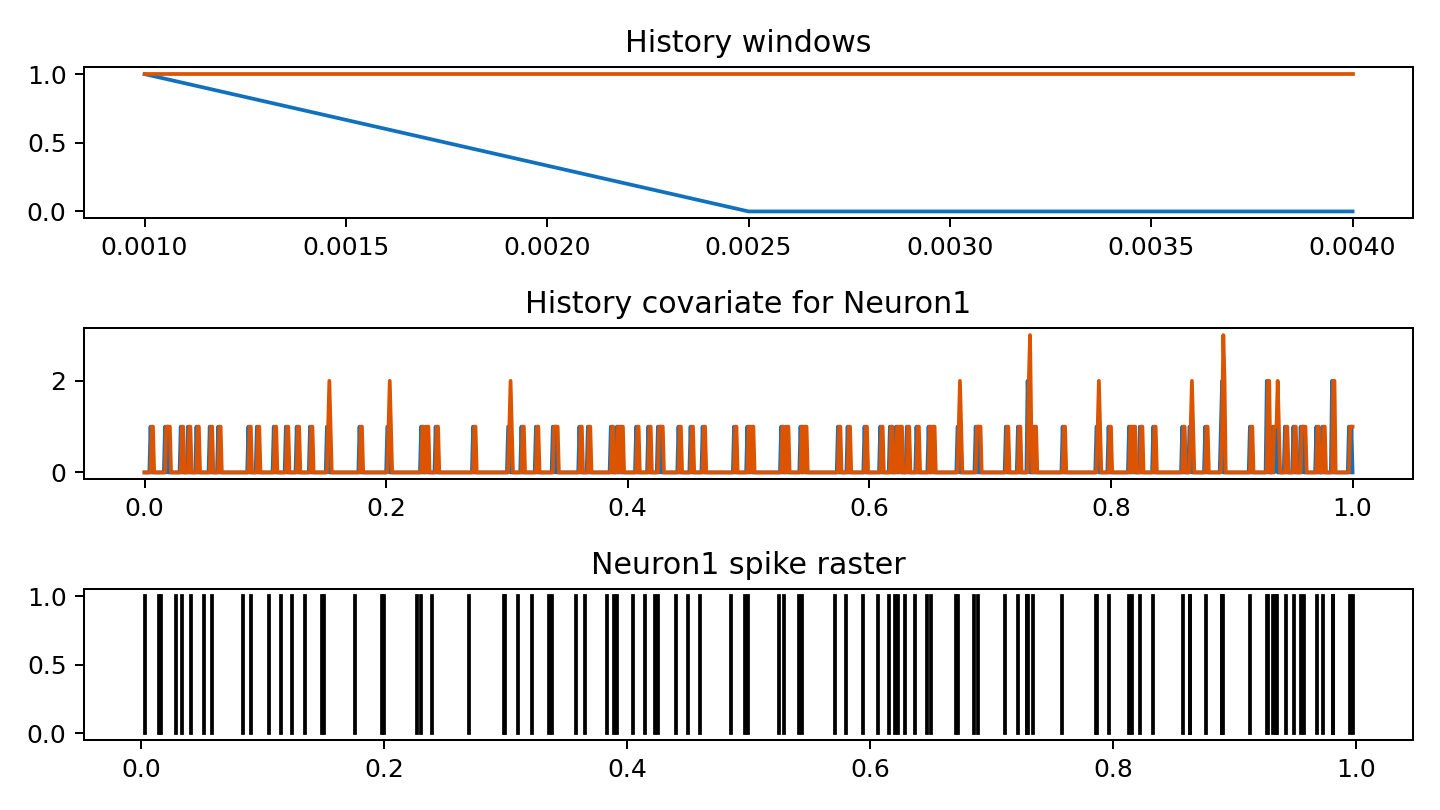

In [2]:
# SECTION 1: Example 1: History covariates for one neural spike train
# Matches MATLAB helpfile ``HistoryExamples.m:7-9``:
#   spikeTimes = sort(rand(1,100))*1;
#   nst        = nspikeTrain(spikeTimes,'n1',.001);
#   windowTimes = [.001 .002 .004];
plt.close("all")
window_times = np.array([0.001, 0.002, 0.004], dtype=float)
h = History(window_times)
rng = np.random.default_rng(0)
spike_times = np.sort(rng.uniform(0.0, 1.0, 100))
nst = nspikeTrain(spike_times, "n1", 1000.0, 0.0, 1.0, makePlots=-1)
histn1 = h.computeHistory(nst, 1)

fig = __tracker.new_figure("history-single-train")
fig.clear()
ax1, ax2, ax3 = fig.subplots(3, 1)
h.plot(handle=ax1)
histn1.getCov(1).plot(handle=ax2)
nst.plot(currentHandle=ax3)
ax1.set_title("History windows")
ax2.set_title("History covariate for Neuron1")
ax3.set_title("Neuron1 spike raster")
fig.tight_layout()

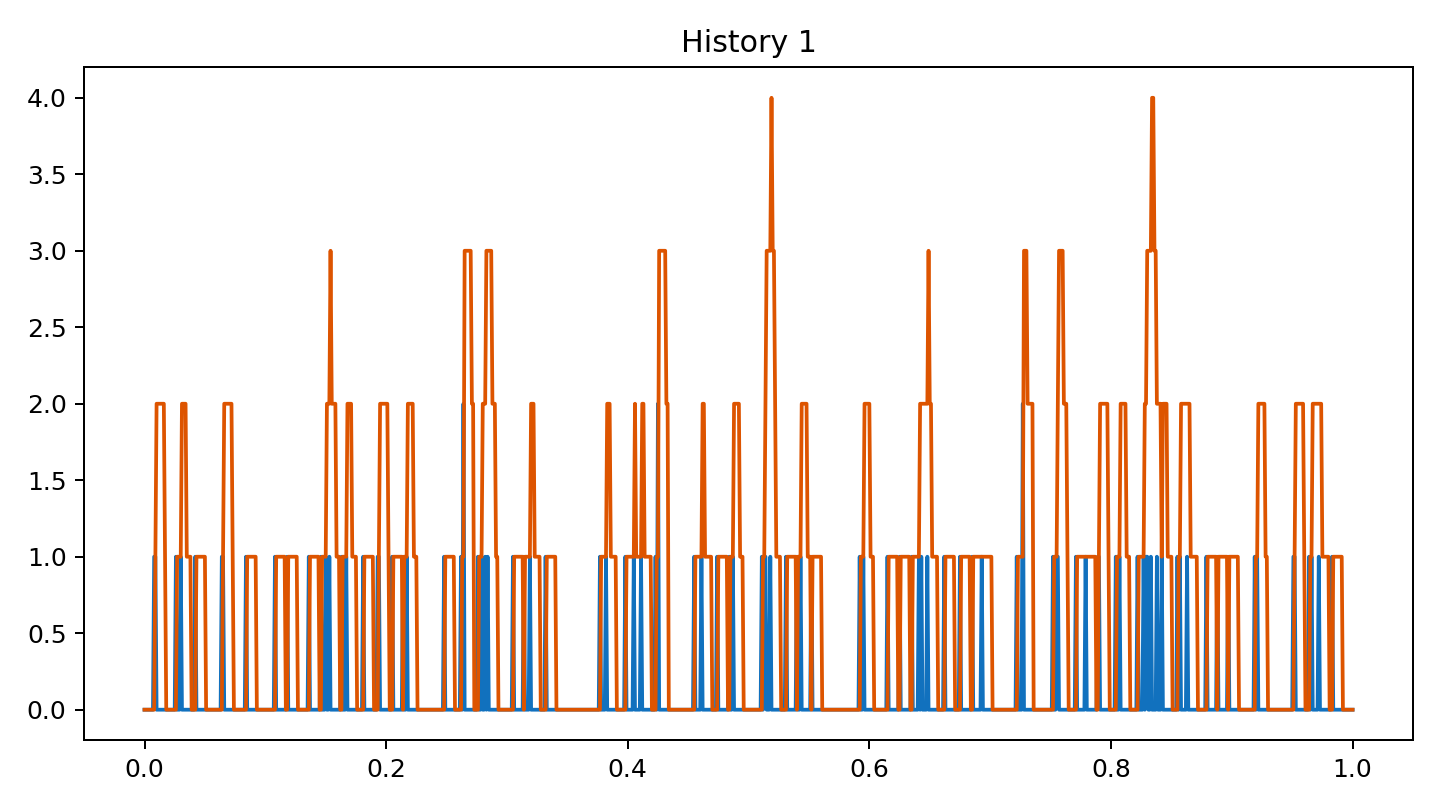

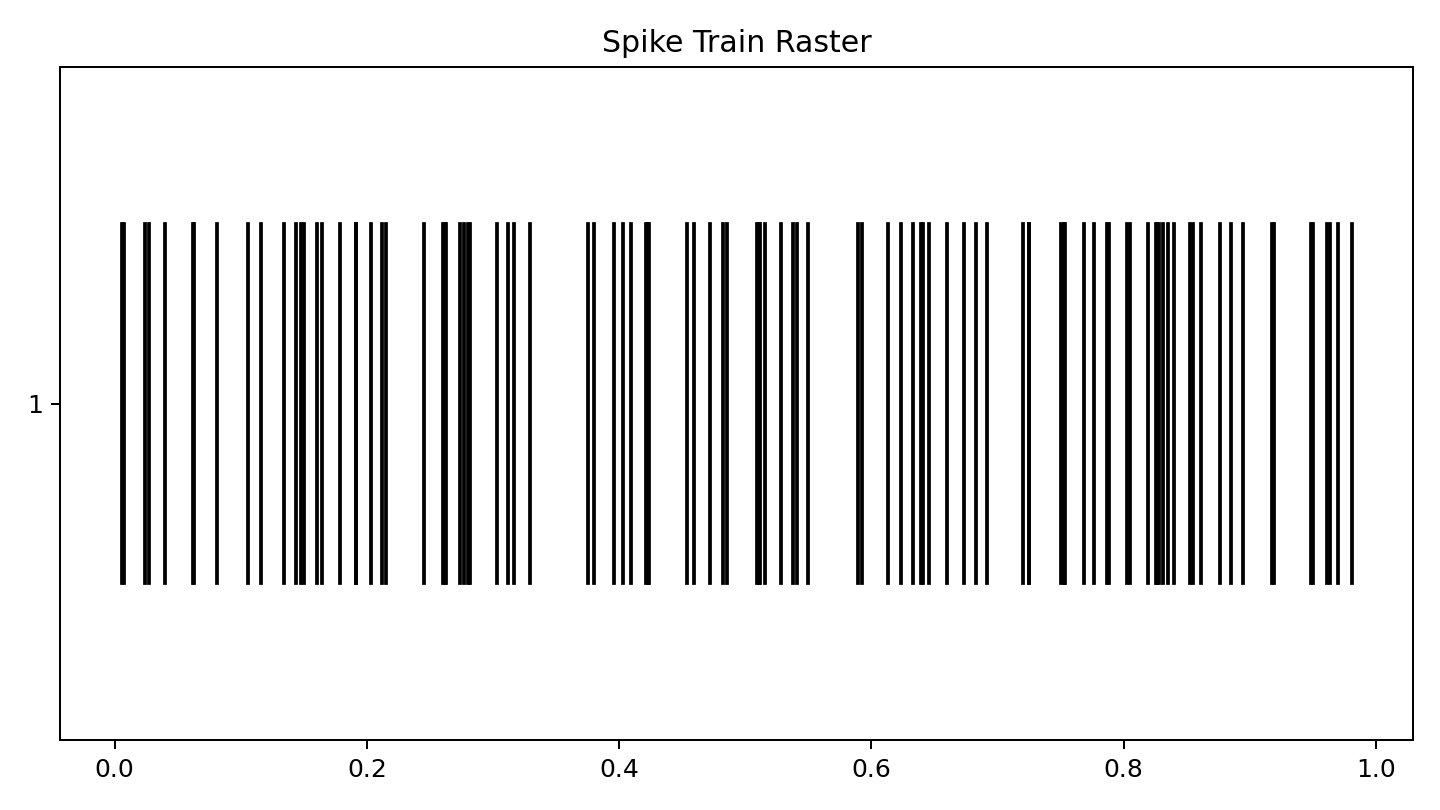

In [3]:
# SECTION 2: Example 2: History covariates for a collection of Neural Spikes (nstColl)
# Matches MATLAB helpfile ``HistoryExamples.m:30-38`` — for i=1:1 loop with
# the same sort(rand(1,100)) draws and a slightly different window.
window_times2 = np.array([0.001, 0.002, 0.010], dtype=float)
h = History(window_times2)
rng2 = np.random.default_rng(1)
spike_times2 = np.sort(rng2.uniform(0.0, 1.0, 100))
nst2 = nspikeTrain(spike_times2, "", 1000.0, 0.0, 1.0, makePlots=-1)
coll = nstColl([nst2])
histColl = h.computeHistory(coll)

fig = __tracker.new_figure("history-collection")
fig.clear()
axes = fig.subplots(histColl.numCov, 1, sharex=True)
if histColl.numCov == 1:
    axes = [axes]
for idx, ax in enumerate(axes, start=1):
    histColl.getCov(idx).plot(handle=ax)
    ax.set_title(histColl.getCov(idx).name)
fig.tight_layout()

fig = __tracker.new_figure("spike-collection")
fig.clear()
ax = fig.subplots(1, 1)
coll.plot(handle=ax)
fig.tight_layout()
__tracker.finalize()